# Weather Data Analysis Using Python

## Project Overview

This project analyzes historical weather data to identify trends, patterns, and relationships between different weather conditions.

The analysis focuses on understanding temperature, humidity, wind speed, visibility, atmospheric pressure, and weather conditions using Python.

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib

### Objective
To explore historical weather data, identify meaningful patterns, and generate data-driven insights through exploratory data analysis (EDA).

## 1. Import Libraries

The following Python libraries are used for data manipulation, numerical analysis, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Load Dataset

The dataset contains hourly historical weather observations.

I will load the CSV file into a Pandas DataFrame for further analysis.

In [ ]:
df = pd.read_csv('Project 1 - Weather Dataset.csv')
df.head()


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


## 3. Dataset Overview


In [ ]:
df.shape

(8784, 8)

In [ ]:
df.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [ ]:
df.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


## 4. Data Quality Check

Before analysis, I will check the dataset for:

- Missing values
- Duplicate records
- Incorrect data types
- Basic data consistency

In [ ]:
df.isnull().sum()

,0
Date/Time,0
Temp_C,0
Dew Point Temp_C,0
Rel Hum_%,0
Wind Speed_km/h,0
Visibility_km,0
Press_kPa,0
Weather,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Date/Time,object
Temp_C,float64
Dew Point Temp_C,float64
Rel Hum_%,int64
Wind Speed_km/h,int64
Visibility_km,float64
Press_kPa,float64
Weather,object


### Data Quality Summary

The dataset was checked for missing values, duplicate records, and data types before beginning the analysis.

In [ ]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])


df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [ ]:
df['Date/Time'].min(), df['Date/Time'].max()

(Timestamp('2012-01-01 00:00:00'), Timestamp('2012-12-31 23:00:00'))

In [ ]:
df['Temp_C'].min(), df['Temp_C'].max()

(-23.3, 33.0)

In [ ]:
df['Rel Hum_%'].min(), df['Rel Hum_%'].max()

(18, 100)

**Finding:** Relative humidity values are within the expected 0–100% range.

In [ ]:
df[df['Visibility_km'] < 0]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather


In [ ]:
df[df['Wind Speed_km/h'] < 0]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather


In [ ]:
df[df['Press_kPa'] <= 0]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather


In [ ]:
df['Year'] = df['Date/Time'].dt.year

In [ ]:
df['Month'] = df['Date/Time'].dt.month

In [ ]:
df['Month_Name'] = df['Date/Time'].dt.month_name()

In [ ]:
df['Day'] = df['Date/Time'].dt.day

In [ ]:
df['Hour'] = df['Date/Time'].dt.hour

In [ ]:
df['Day_of_Week'] = df['Date/Time'].dt.day_name()

In [ ]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(season)
seasonal = df.groupby("Season").mean(numeric_only=True)


In [ ]:
df['Season'] = df['Month'].apply(season)

In [ ]:
df[['Date/Time', 'Month', 'Month_Name', 'Season']].head()

,Date/Time,Month,Month_Name,Season
0,2012-01-01 00:00:00,1,January,Winter
1,2012-01-01 01:00:00,1,January,Winter
2,2012-01-01 02:00:00,1,January,Winter
3,2012-01-01 03:00:00,1,January,Winter
4,2012-01-01 04:00:00,1,January,Winter


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date/Time         8784 non-null   datetime64[ns]
 1   Temp_C            8784 non-null   float64       
 2   Dew Point Temp_C  8784 non-null   float64       
 3   Rel Hum_%         8784 non-null   int64         
 4   Wind Speed_km/h   8784 non-null   int64         
 5   Visibility_km     8784 non-null   float64       
 6   Press_kPa         8784 non-null   float64       
 7   Weather           8784 non-null   object        
 8   Year              8784 non-null   int32         
 9   Month             8784 non-null   int32         
 10  Day               8784 non-null   int32         
 11  Hour              8784 non-null   int32         
 12  Day_of_Week       8784 non-null   object        
 13  Season            8784 non-null   object        
 14  Month_Name        8784 n

In [ ]:
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Year,Month,Day,Hour,Day_of_Week,Season,Month_Name
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog,2012,1,1,0,Sunday,Winter,January
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog,2012,1,1,1,Sunday,Winter,January
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog",2012,1,1,2,Sunday,Winter,January
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog",2012,1,1,3,Sunday,Winter,January
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog,2012,1,1,4,Sunday,Winter,January


In [ ]:
df.shape

(8784, 15)

## 5 Data Cleaning Summary

The dataset was prepared for exploratory analysis through the following steps:

- Checked for missing values
- Checked for duplicate records
- Converted `Date/Time` to datetime format
- Validated numerical data types
- Checked for invalid values
- Created time-based features including Year, Month, Day, Hour, and Day of Week
- Created a Season feature for seasonal analysis

The cleaned dataset is now ready for exploratory data analysis.

# 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of weather variables, identify patterns and extreme observations, and explore relationships between different weather conditions.

The analysis is driven by specific questions rather than only visualizing the data.

#### Questions

- What is the typical temperature in the dataset?
- What are the minimum and maximum temperatures?
- How is temperature distributed?
- How does temperature vary over time?

In [ ]:


df['Temp_C'].describe()

,Temp_C
count,8784.000000
mean,8.798144
std,11.687883
min,-23.300000
25%,0.100000
50%,9.300000
75%,18.800000
max,33.000000


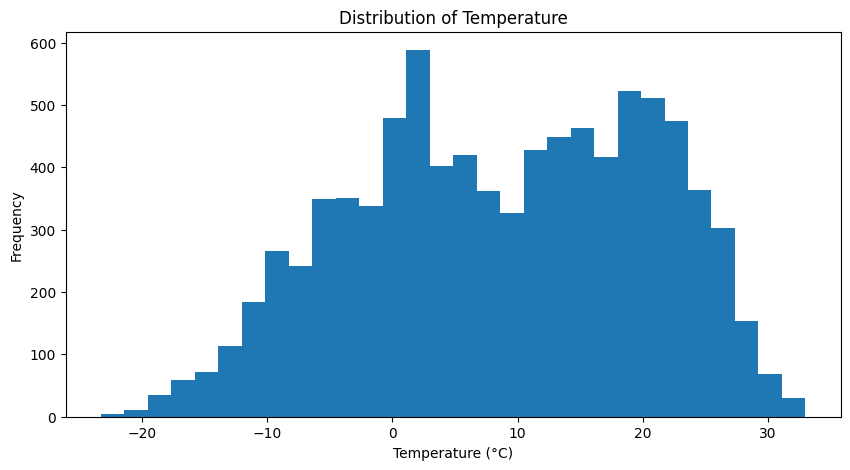

In [ ]:

plt.figure(figsize=(10, 5))

plt.hist(df['Temp_C'], bins=30)

plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

plt.show()

### Insight

Temperature showed substantial seasonal variation, ranging from -23.3°C to 33.0°C, with an average of 8.8°C.

### Insight
The temperature distribution shows how frequently different temperature ranges occur in the dataset. The distribution can be used to understand typical conditions as well as unusually cold or warm observations.

In [ ]:
#Extremely cold
cold_days = df[df['Temp_C'] < -10]

len(cold_days)

494

In [ ]:
cold_percentage = (len(cold_days) / len(df)) * 100

cold_percentage

5.623861566484517

### Insight
Approximately 5.6% of observations recorded temperatures below -10°C.

Approximately  5.6% of observations recorded temperatures below -10°C.

In [ ]:
#Extremely warm
hot_days = df[df['Temp_C'] > 30]

len(hot_days)

67

In [ ]:
hot_percentage = (len(hot_days) / len(df)) * 100

hot_percentage

0.7627504553734062

### Insight
Only 0.76% of hourly observations exceeded 30°C, indicating that extreme high temperatures were rare compared with colder conditions in this dataset

###  Humidity Analysis

####Questions
What is the typical relative humidity?
How is humidity distributed?
Does humidity vary across seasons?

In [ ]:
df['Rel Hum_%'].describe()

,Rel Hum_%
count,8784.000000
mean,67.431694
std,16.918881
min,18.000000
25%,56.000000
50%,68.000000
75%,81.000000
max,100.000000


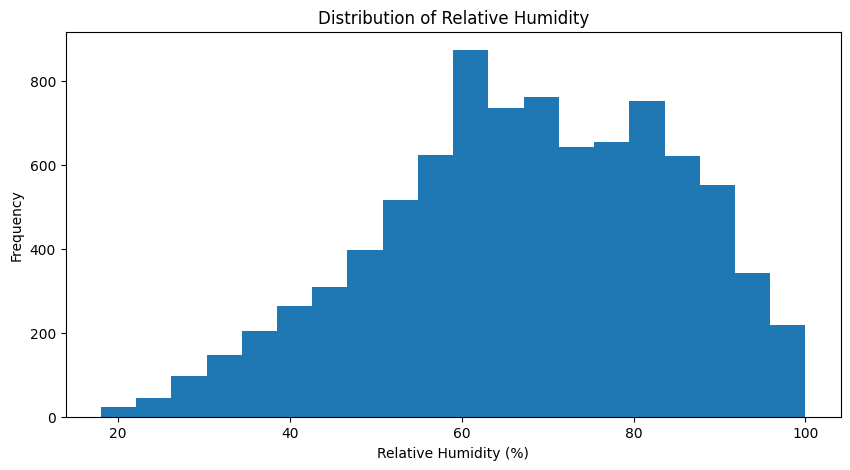

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df['Rel Hum_%'], bins=20)

plt.title('Distribution of Relative Humidity')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Frequency')

plt.show()

###insight
Most observations fall within the 60 - 80% humidity range.

###  Weather Condition Analysis

#### Questions
Which weather conditions occur most frequently?

Which conditions are relatively uncommon?

What weather conditions are associated with poor visibility?

In [ ]:
weather_counts = df['Weather'].value_counts()

weather_counts.head(10)

,count
Weather,
Mainly Clear,2106
Mostly Cloudy,2069
Cloudy,1728
Clear,1326
Snow,390
Rain,306
Rain Showers,188
Fog,150
"Rain,Fog",116


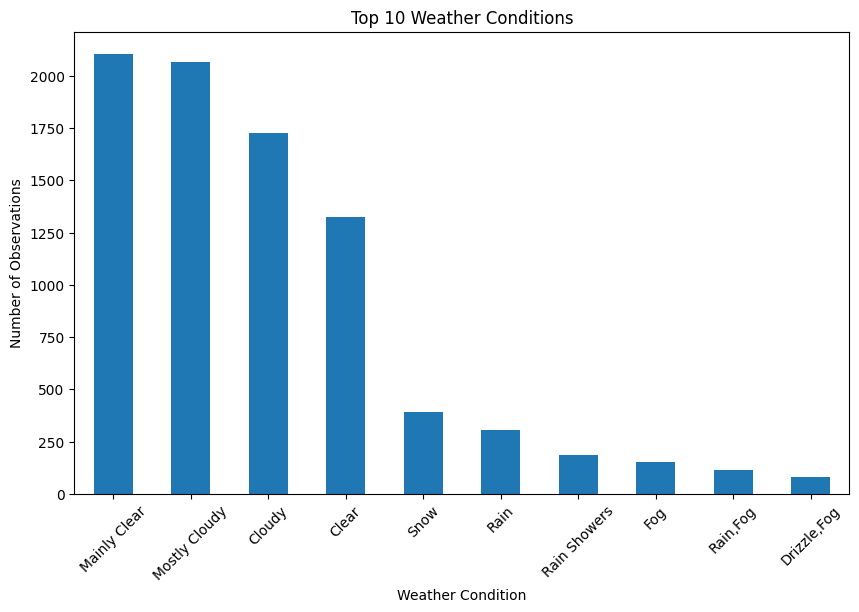

In [ ]:
plt.figure(figsize=(10, 6))

weather_counts.head(10).plot(kind='bar')

plt.title('Top 10 Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Observations')

plt.xticks(rotation=45)

plt.show()

### Insight
Mainly Clear and Mostly Cloudy were the two most frequently observed weather conditions, while snow, rain, and fog occurred substantially less often.

###  Visibility Analysis

#### Questions
 What is the typical visibility?

 How frequently does low visibility occur?

 Which weather conditions are associated with low visibility?

In [ ]:
df['Visibility_km'].describe()

,Visibility_km
count,8784.000000
mean,27.664447
std,12.622688
min,0.200000
25%,24.100000
50%,25.000000
75%,25.000000
max,48.300000


In [ ]:
low_visibility = df[df['Visibility_km'] < 2]

len(low_visibility)


98

In [ ]:
low_visibility_percentage = (len(low_visibility) / len(df)) * 100

low_visibility_percentage

1.1156648451730418

In [ ]:
low_visibility['Weather'].value_counts()

,count
Weather,
Snow,43
Fog,27
"Snow,Blowing Snow",9
"Snow,Fog",5
Freezing Fog,4
Moderate Snow,4
"Drizzle,Fog",4
"Moderate Snow,Blowing Snow",2


### Insight
Snow was the most common weather condition associated with very low visibility (<2 km), accounting for approximately 43.9% of low-visibility observations. Fog-related conditions also appeared frequently, suggesting that snow and fog were major contributors to reduced visibility in this dataset.

### Wind Speed Analysis

#### Questions
 What is the typical wind speed?

 What is the maximum recorded wind speed?

 How does wind speed vary across seasons?

In [ ]:
df['Wind Speed_km/h'].describe()

,Wind Speed_km/h
count,8784.000000
mean,14.945469
std,8.688696
min,0.000000
25%,9.000000
50%,13.000000
75%,20.000000
max,83.000000


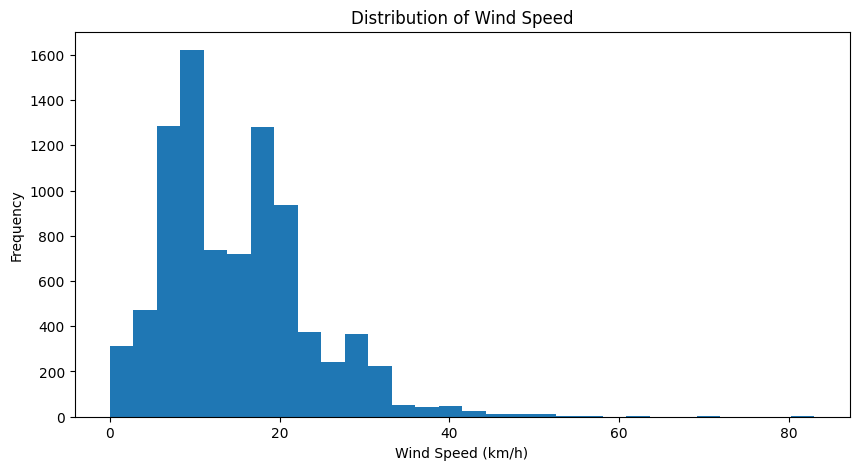

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df['Wind Speed_km/h'], bins=30)

plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Frequency')

plt.show()

### Insight
Average wind speed was approximately 14.9 km/h, while the maximum recorded value reached 83 km/h, indicating occasional high-wind conditions within the dataset.

###  Time-Based Analysis

The hourly weather observations are analyzed across different time periods to identify recurring patterns.

#### Questions
How does temperature change throughout the day?
Which hours have the highest and lowest average temperatures?
Are there noticeable daily patterns?

In [ ]:
hourly_temp = df.groupby('Hour')['Temp_C'].mean()

hourly_temp

,Temp_C
Hour,
0,7.568579
1,7.090437
2,6.656011
3,6.291803
4,5.969126
5,5.717760
6,6.033060
7,6.572951
8,7.378142


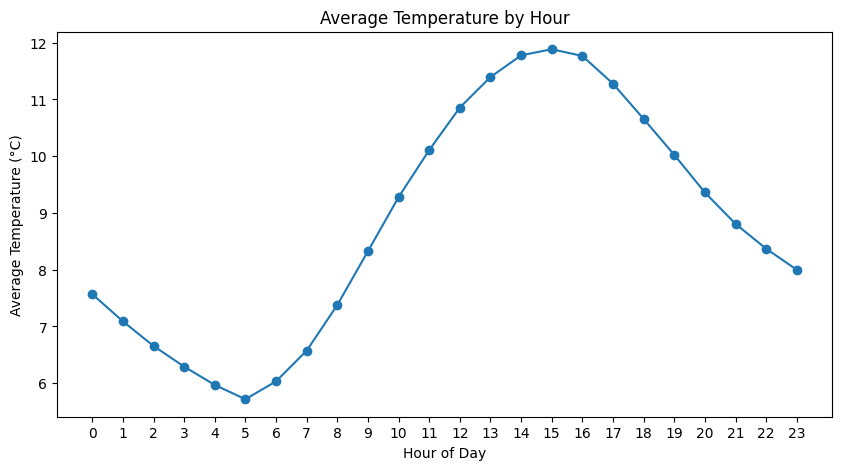

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_temp.index, hourly_temp.values, marker='o')

plt.title('Average Temperature by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(0, 24))

plt.show()

### Insight
Average temperature followed a clear daily cycle, reaching its lowest level around 5 AM (5.7°C) and peaking around 3 PM (11.9°C) before gradually declining through the evening.

###  Monthly Temperature Analysis

#### Question

 How does average temperature vary across the months?

In [ ]:
monthly_temp = df.groupby('Month')['Temp_C'].mean()

monthly_temp

,Temp_C
Month,
1,-7.371505
2,-4.225000
3,3.121237
4,7.009306
5,16.237769
6,20.134028
7,22.790054
8,22.279301
9,16.484444


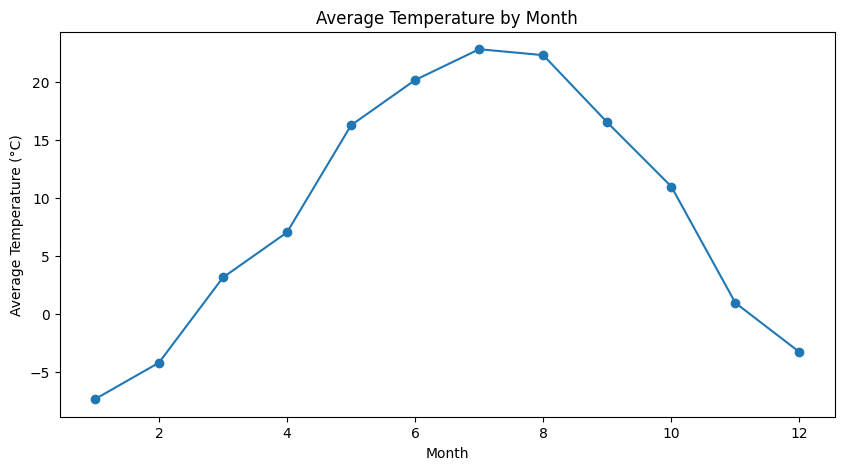

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o')

plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')

plt.show()

### Insight
Temperature increased steadily from winter into summer, reaching its highest monthly average of 22.8°C in July, before declining through autumn and returning to negative averages in December.

###  Seasonal Analysis

#### Questions
 Which season has the highest average temperature?
 Which season has the highest humidity?
 How does wind speed vary across seasons?

In [ ]:
season_summary = df.groupby('Season')[
    ['Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km']
].mean()

season_summary

,Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km
Season,,,,
Autumn,9.473397,72.331502,14.529762,27.240201
Spring,8.808786,60.976449,14.883605,29.095697
Summer,21.751857,63.566123,13.487319,31.982654
Winter,-4.983929,72.966117,16.897894,22.276053


### Correlation Analysis

Correlation analysis is used to examine relationships between numerical weather variables.

 The analysis focuses on identifying variables that move together and understanding the strength and direction of their relationships.

In [ ]:
numeric_cols = [
    'Temp_C',
    'Dew Point Temp_C',
    'Rel Hum_%',
    'Wind Speed_km/h',
    'Visibility_km',
    'Press_kPa'
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Temp_C,1.000000,0.932714,-0.220182,-0.061876,0.273455,-0.236389
Dew Point Temp_C,0.932714,1.000000,0.139494,-0.095685,0.050813,-0.320616
Rel Hum_%,-0.220182,0.139494,1.000000,-0.092743,-0.633683,-0.231424
Wind Speed_km/h,-0.061876,-0.095685,-0.092743,1.000000,0.004883,-0.356613
Visibility_km,0.273455,0.050813,-0.633683,0.004883,1.000000,0.231847
Press_kPa,-0.236389,-0.320616,-0.231424,-0.356613,0.231847,1.000000


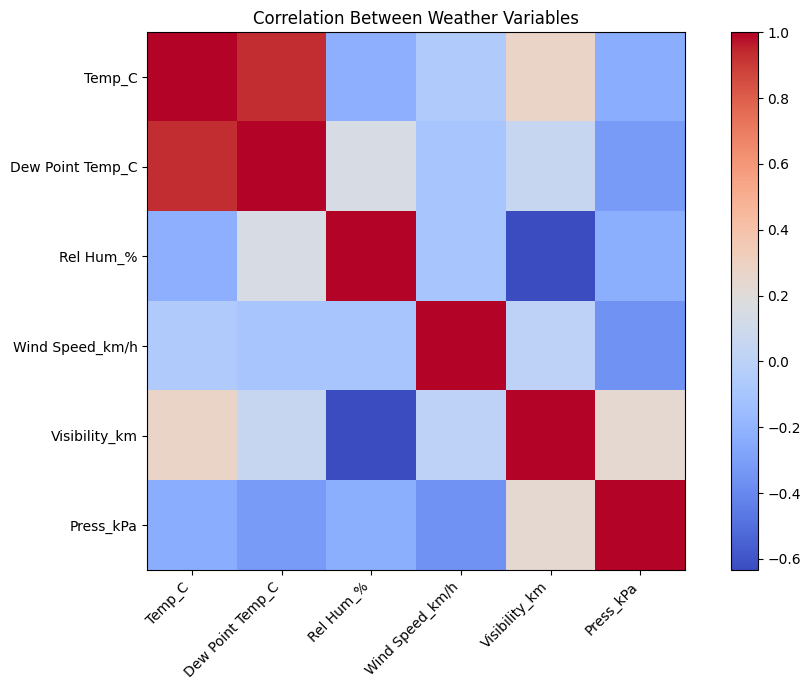

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap='coolwarm')

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Between Weather Variables')

plt.tight_layout()

plt.show()

### Insight
#### Higher humidity was associated with lower visibility.
Temperature and dew point temperature showed a very strong positive correlation (r = 0.933), indicating that they tend to increase and decrease together.

Relative humidity and visibility showed a moderate negative correlation (r = -0.634), indicating that higher humidity was generally associated with lower visibility in the dataset.

# 7. Key Findings

1. **Temperature Variation:** Temperature ranged from -23.3°C to 33.0°C, with an average of 8.8°C, showing substantial variation across the year.

2. **Extreme Temperatures:** Approximately 5.6% of hourly observations recorded temperatures below -10°C, compared with only 0.76% above 30°C.

3. **Weather Conditions:** The four most frequent weather conditions — Mainly Clear, Mostly Cloudy, Cloudy, and Clear — accounted for approximately 82.3% of all observations.

4. **Low Visibility:** Only 1.12% of observations recorded visibility below 2 km. Snow was the most common condition during these low-visibility observations.

5. **Daily Temperature Pattern:** Average temperature reached its lowest level around 5 AM and peaked around 3 PM, showing a clear daily temperature cycle.

6. **Seasonal Variation:** Summer recorded the highest average temperature and visibility, while winter recorded the lowest temperature and visibility and the highest average wind speed.

7. **Correlation:** Temperature and dew point showed a very strong positive correlation (r = 0.933), while relative humidity and visibility showed a moderate negative correlation (r = -0.634).

# 8. Practical Implications

The analysis highlights several patterns that could support weather-sensitive decision-making:

- **Transportation & Logistics:** Low-visibility conditions, particularly during snow and fog, may require additional planning for transportation operations.

- **Outdoor Activities:** Strong seasonal and daily temperature patterns can support planning for outdoor events and activities.

- **Operational Planning:** Seasonal variations in wind speed and visibility can help organizations prepare for changing environmental conditions.

- **Weather Monitoring:** Understanding the relationship between humidity and visibility may help identify periods where visibility conditions require closer monitoring.

These findings demonstrate how historical weather data can be transformed into practical insights for weather-sensitive operations.

# 9. Conclusion

This project used Python to explore historical weather data and identify patterns across temperature, humidity, wind speed, visibility, atmospheric pressure, and weather conditions.

The analysis demonstrated how data cleaning, exploratory analysis, time-based analysis, visualization, and correlation analysis can be combined to extract meaningful insights from raw data.

This project also strengthened my understanding of using Python for real-world data analysis and converting data into actionable findings.